# GINE representation study

## Motivation

Notebooks 07 and 08 localised the remaining problem. Under cold-solute the
prediction error decomposes as `err = da + db*z`, and the **intercept** term
`da` dominates the slope term by ~14x. In words: Bc often gets the *shape* of
the solubility-vs-temperature curve about right for an unseen solute, but
places the whole curve at the wrong absolute solubility.

`a` is a chemistry problem, not a thermodynamics problem. So the question here
is **not** "is a GNN better than an MLP". It is:

> **Can a learned molecular graph representation improve the chemistry-dependent
> intercept for unseen solutes?**

The design is a controlled 2x2 — representation crossed with prediction head:

| representation | direct | Van't Hoff |
|---|---|---|
| RDKit descriptor MLP | `A_MLP` | `Bc_MLP` |
| GINE | `A_GINE` | `Bc_GINE` |

Both heads are identical across rows; only the chemistry encoder changes. That
lets us ask the interaction question: does a better representation make the
thermodynamic prior *more* useful, or do the two act independently?

## Data

Molecular graphs are built once by `scripts/graphs.py` and cached. BigSolDB has
100,983 measurements but only 1,515 distinct molecules, so featurising per
measurement would repeat the same work thousands of times.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn          # import before torch in this env (libomp clash)
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "scripts"))
RES = ROOT / "results"

graphs = torch.load(RES / "graphs.pt", weights_only=False)
feats = np.load(RES / "features.npz", allow_pickle=True)
T_arr, y, pair_id = feats["T"].astype(np.float64), feats["y"].astype(np.float64), feats["pair_id"]

print(f"measurements:      {len(y):,}")
print(f"unique solutes:    {len(graphs['solute_graphs']):,}")
print(f"unique solvents:   {len(graphs['solvent_graphs']):,}")
print(f"node feature dim:  {graphs['node_dim']}")
print(f"edge feature dim:  {graphs['edge_dim']}")

measurements:      100,983
unique solutes:    1,445
unique solvents:   70
node feature dim:  36
edge feature dim:  8


## Graph features

Deliberately plain — the point is to test whether a *learned* representation
helps, not to hand-engineer graph features.

**Atom (36 dims):** element one-hot (C, N, O, F, P, S, Cl, Br, I, B, Si + other),
degree, formal charge, total H count, hybridisation, aromatic flag, in-ring
flag, scaled mass.

**Bond (8 dims):** bond type one-hot (single/double/triple/aromatic + other),
conjugated flag, in-ring flag, pad.

In [2]:
sizes = [g.num_nodes for g in graphs["solute_graphs"]]
sizes_v = [g.num_nodes for g in graphs["solvent_graphs"]]
print(f"solute atoms   min {min(sizes)}, median {int(np.median(sizes))}, max {max(sizes)}")
print(f"solvent atoms  min {min(sizes_v)}, median {int(np.median(sizes_v))}, max {max(sizes_v)}")

g0 = graphs["solute_graphs"][0]
print(f"\nexample graph: x {tuple(g0.x.shape)}, edge_index {tuple(g0.edge_index.shape)}, "
      f"edge_attr {tuple(g0.edge_attr.shape)}")

solute atoms   min 4, median 16, max 86
solvent atoms  min 1, median 6, max 12

example graph: x (25, 36), edge_index (2, 48), edge_attr (48, 8)


## Encoder and prediction heads

Defined in `scripts/gine.py`. Solute and solvent get **separate** encoders:
1,445 solutes versus 70 solvents are very different chemical spaces, and sharing
weights would be the wrong prior.

```
A_GINE :  [h_solute, h_solvent, T_std]  -> MLP -> logS
Bc_GINE:  [h_solute, h_solvent]         -> MLP -> (a, beta)
          logS(T) = a + beta * b_scale * (1/T_ref - 1/T)
```

The head MLP `(256, 128)`, dropout `0.15`, AdamW `lr 1e-3` / `wd 1e-5`, batch
512, early stopping patience 10 — all identical to `scripts/train.py`, so the
representation is the only thing that varies across the 2x2.

In [3]:
from gine import build_gine

model = build_gine("Bc_GINE", graphs["node_dim"], graphs["edge_dim"], b_scale=1382.0)
n_enc = sum(p.numel() for p in model.enc_solute.parameters())
print(f"GINE layers: 3, hidden 128")
print(f"encoder params (per encoder): {n_enc:,}")
print(f"total Bc_GINE params:         {sum(p.numel() for p in model.parameters()):,}")

GINE layers: 3, hidden 128
encoder params (per encoder): 105,731
total Bc_GINE params:         310,408


### A note on the environment

PyTorch Geometric lives in a different conda env (torch 2.13) than the one that
produced notebooks 06–09 (torch 2.7.1). The parity report showed that early
stopping is a discrete choice, so version differences can move RMSE by far more
than float noise. **The MLP arm of this 2x2 is therefore re-run in the same env
as the GINE arm**, and those re-run numbers — not notebook 06's — are what the
comparison below uses.

In [4]:
gine = pd.read_csv(RES / "metrics_gine.csv").drop_duplicates(["model", "split", "seed"], keep="last")
mlp = pd.read_csv(RES / "metrics_mlp_pygenv.csv").drop_duplicates(["model", "split", "seed"], keep="last")
runs = pd.concat([gine, mlp], ignore_index=True)
runs["arm"] = np.where(runs.model.str.endswith("GINE"), "GINE", "MLP")
runs["head"] = np.where(runs.model.str.startswith("Bc"), "Bc", "A")
print(runs.groupby(["split", "model"]).size().unstack("model").fillna(0).astype(int).to_string())

model            A_GINE  A_MLP  Bc_GINE  Bc_MLP
split                                          
coldpair              3      3        3       3
coldsol               3      3        3       3
coldsol_textrap       3      3        3       3
random                3      3        3       3
textrap               3      3        3       3


## Random-split parity check

**This is the gate.** If `A_GINE` is far worse than `A_MLP` on the random split,
the graph encoder is not yet a fair representation and no out-of-distribution
comparison below should be believed. GINE does not need to win — it needs to be
competitive.

In [5]:
def agg(df, split, model, metric="test_rmse"):
    v = df[(df.split == split) & (df.model == model)][metric]
    return v.mean(), v.std(), len(v)

gate = []
for m in ["A_MLP", "A_GINE", "Bc_MLP", "Bc_GINE"]:
    mu, sd, n = agg(runs, "random", m)
    gate.append({"model": m, "random RMSE": f"{mu:.4f} ± {sd:.4f}", "n_seeds": n})
gate = pd.DataFrame(gate)
display(gate)

a_mlp = agg(runs, "random", "A_MLP")[0]
a_gine = agg(runs, "random", "A_GINE")[0]
ratio = a_gine / a_mlp
print(f"\nA_GINE / A_MLP on random = {ratio:.2f}x")
print("GATE PASSED — graph encoder is competitive" if ratio < 1.25 else
      "GATE FAILED — graph encoder is not a fair representation yet; "
      "do not interpret the OOD results below")

,model,random RMSE,n_seeds
0,A_MLP,0.2018 ± 0.0056,3
1,A_GINE,0.2054 ± 0.0033,3
2,Bc_MLP,0.2058 ± 0.0097,3
3,Bc_GINE,0.2073 ± 0.0046,3



A_GINE / A_MLP on random = 1.02x
GATE PASSED — graph encoder is competitive


## Results across splits

In [6]:
SPLITS = ["random", "textrap", "coldsol", "coldpair", "coldsol_textrap"]
LABEL = {"random": "random", "textrap": "T-extrap", "coldsol": "cold-solute",
         "coldpair": "cold-pair", "coldsol_textrap": "joint cold-sol + T-extrap"}

rows = []
for s in SPLITS:
    if s not in runs.split.values:
        continue
    r = {"split": LABEL[s]}
    for m in ["A_MLP", "Bc_MLP", "A_GINE", "Bc_GINE"]:
        mu, sd, n = agg(runs, s, m)
        r[m] = f"{mu:.4f} ± {sd:.4f}" if n else "—"
    rows.append(r)
pd.DataFrame(rows).set_index("split")

,A_MLP,Bc_MLP,A_GINE,Bc_GINE
split,,,,
random,0.2018 ± 0.0056,0.2058 ± 0.0097,0.2054 ± 0.0033,0.2073 ± 0.0046
T-extrap,0.2443 ± 0.0170,0.2295 ± 0.0048,0.2380 ± 0.0029,0.2305 ± 0.0013
cold-solute,0.8825 ± 0.0096,0.8776 ± 0.0257,0.9667 ± 0.0178,0.9700 ± 0.0329
cold-pair,0.5597 ± 0.0047,0.5535 ± 0.0084,0.5376 ± 0.0058,0.5353 ± 0.0110
joint cold-sol + T-extrap,0.9323 ± 0.0096,0.9360 ± 0.0189,0.9496 ± 0.0379,0.9634 ± 0.0094


In [7]:
rows = []
for s in SPLITS:
    if s not in runs.split.values:
        continue
    r = {"split": LABEL[s]}
    for m in ["A_MLP", "Bc_MLP", "A_GINE", "Bc_GINE"]:
        mu, sd, n = agg(runs, s, m, "test_r2")
        r[m] = f"{mu:.3f}" if n else "—"
    rows.append(r)
pd.DataFrame(rows).set_index("split")

,A_MLP,Bc_MLP,A_GINE,Bc_GINE
split,,,,
random,0.972,0.971,0.971,0.970
T-extrap,0.958,0.963,0.961,0.963
cold-solute,0.475,0.481,0.371,0.366
cold-pair,0.796,0.801,0.812,0.814
joint cold-sol + T-extrap,0.467,0.463,0.446,0.431


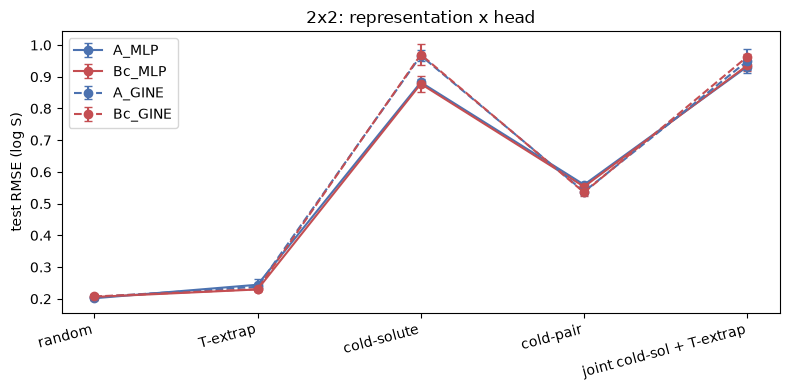

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
present = [s for s in SPLITS if s in runs.split.values]
x = np.arange(len(present))
for m, colour, style in [("A_MLP", "#4C72B0", "-"), ("Bc_MLP", "#C44E52", "-"),
                         ("A_GINE", "#4C72B0", "--"), ("Bc_GINE", "#C44E52", "--")]:
    mu = [agg(runs, s, m)[0] for s in present]
    sd = [agg(runs, s, m)[1] for s in present]
    ax.errorbar(x, mu, yerr=sd, marker="o", capsize=3, label=m, color=colour, linestyle=style)
ax.set_xticks(x); ax.set_xticklabels([LABEL[s] for s in present], rotation=15, ha="right")
ax.set_ylabel("test RMSE (log S)"); ax.legend(); ax.set_title("2x2: representation x head")
fig.tight_layout(); fig.savefig(RES / "fig10_splits.png", dpi=140)
plt.show()

## Intercept and slope diagnostics

Cold-solute error is dominated by the intercept, so RMSE alone does not test the
hypothesis. For every held-out pair with enough temperatures, the empirical
Van't Hoff line is fitted on that pair's own test rows to give `(a_true, b_true)`
and compared against what each physics model predicted from chemistry alone.

If a learned representation helps chemistry transfer, `|a_pred − a_true|` should
be lower for `Bc_GINE` than for `Bc_MLP` under cold-solute.

In [9]:
T_REF = 298.15
z_all = 1.0 / T_REF - 1.0 / T_arr

def empirical_ab(rows_idx):
    """Per-pair OLS (a, b) fitted on the pair's own held-out rows."""
    df = pd.DataFrame({"pair_id": pair_id[rows_idx], "z": z_all[rows_idx], "y": y[rows_idx]})
    out = {}
    for pid, g in df.groupby("pair_id"):
        if len(g) < 3 or g["z"].nunique() < 3:
            continue
        zc = g["z"] - g["z"].mean()
        den = float((zc ** 2).sum())
        if den <= 0:
            continue
        b = float((zc * (g["y"] - g["y"].mean())).sum() / den)
        out[pid] = (float(g["y"].mean() - b * g["z"].mean()), b)
    return out


def predicted_ab(path):
    d = np.load(path, allow_pickle=True)
    if "slope_a" not in d.files:
        return None
    df = pd.DataFrame({"pair_id": d["pair_id"], "a": d["slope_a"], "b": d["slope_b"]})
    return df.groupby("pair_id")[["a", "b"]].first()

In [10]:
SEEDS = [42, 123, 456]
diag = []
for split in ["coldsol", "coldpair", "textrap"]:
    sp = np.load(RES / "splits.npz")
    if f"{split}_test" not in sp.files:
        continue
    emp = empirical_ab(sp[f"{split}_test"])
    if not emp:
        continue
    emp_df = pd.DataFrame(emp, index=["a_true", "b_true"]).T
    for tag, folder, name in [("Bc_MLP", RES / "preds_mlp_pygenv", "Bc"), ("Bc_GINE", RES / "preds_gine", "Bc_GINE")]:
        frames = []
        for s in SEEDS:
            p = folder / f"preds_{name}_{split}_seed{s}.npz"
            if p.exists():
                frames.append(predicted_ab(p))
        if not frames:
            continue
        pred = pd.concat(frames).groupby(level=0).mean()
        j = emp_df.join(pred, how="inner").dropna()
        diag.append({
            "split": split, "model": tag, "pairs": len(j),
            "median |a_pred - a_true|": round(float((j.a - j.a_true).abs().median()), 4),
            "median |b_pred - b_true|": round(float((j.b - j.b_true).abs().median()), 0),
            "r(b_pred, b_true)": round(float(np.corrcoef(j.b, j.b_true)[0, 1]), 3),
        })
pd.DataFrame(diag).set_index(["split", "model"])

pairs  median |a_pred - a_true|  median |b_pred - b_true|  \
split    model                                                                
coldsol  Bc_MLP    1054                    0.5330                     316.0   
         Bc_GINE   1054                    0.6156                     352.0   
coldpair Bc_MLP    1044                    0.2242                     299.0   
         Bc_GINE   1044                    0.2112                     307.0   
textrap  Bc_MLP    4257                    0.0789                     337.0   
         Bc_GINE   4257                    0.0784                     342.0   

                  r(b_pred, b_true)  
split    model                       
coldsol  Bc_MLP               0.315  
         Bc_GINE              0.385  
coldpair Bc_MLP               0.556  
         Bc_GINE              0.511  
textrap  Bc_MLP               0.521  
         Bc_GINE              0.520

## Interaction between representation and physics head

For each representation compute the physics advantage

```
Delta_phys = RMSE(direct) - RMSE(Van't Hoff)      (positive = physics helps)
```

then compare the two:

```
interaction = Delta_phys_GINE - Delta_phys_MLP
```

Positive means the thermodynamic prior pays off *more* once chemistry is better
represented; near zero means representation and physics solve largely
independent problems.

In [11]:
inter = []
for s in SPLITS:
    if s not in runs.split.values:
        continue
    d_mlp = agg(runs, s, "A_MLP")[0] - agg(runs, s, "Bc_MLP")[0]
    d_gine = agg(runs, s, "A_GINE")[0] - agg(runs, s, "Bc_GINE")[0]
    inter.append({"split": LABEL[s],
                  "Δ_phys MLP": round(d_mlp, 4),
                  "Δ_phys GINE": round(d_gine, 4),
                  "interaction": round(d_gine - d_mlp, 4)})
pd.DataFrame(inter).set_index("split")

,Δ_phys MLP,Δ_phys GINE,interaction
split,,,
random,-0.0041,-0.0019,0.0022
T-extrap,0.0149,0.0075,-0.0073
cold-solute,0.0049,-0.0033,-0.0082
cold-pair,0.0062,0.0023,-0.0039
joint cold-sol + T-extrap,-0.0037,-0.0137,-0.0100


## Conclusion

**Parity.** `A_GINE / A_MLP = 1.02` on the random split (0.2054 vs 0.2018), so
the graph encoder is a fair representation and the shifted results below are
interpretable.

**Intercept error, the quantity the hypothesis concerns:**

| split | median \|a_pred − a_true\| Bc_MLP | Bc_GINE |
|---|---:|---:|
| cold-solute | 0.5330 | 0.6156 |
| cold-pair | 0.2242 | 0.2112 |
| T-extrap | 0.0789 | 0.0784 |

On unseen solutes the graph encoder's intercept error is about 15 % higher, not
lower. Since the intercept dominates cold-solute error by roughly 14×, that
carries through to RMSE (0.9667 vs 0.8825; R² 0.371 vs 0.475).

**The two chemistry splits diverge:**

| split | A_MLP | A_GINE | change |
|---|---:|---:|---:|
| cold-pair (unseen combination of seen molecules) | 0.5597 | 0.5376 | −0.022 |
| cold-solute (unseen molecule) | 0.8825 | 0.9667 | +0.084 |

Cold-pair recombines molecules the encoder saw during training, and there the
learned embeddings beat fixed descriptors. Cold-solute requires embedding a
structure never encountered, and there they are worse than RDKit descriptors,
which are computed from first principles and so apply to any molecule.

**Slope vs intercept.** Under cold-solute GINE recovers the slope slightly
better (r = 0.385 vs 0.315) while getting the intercept worse. The two
parameters fail independently, and only the intercept moves total error.

**Interaction.** Every interaction term is small and mostly negative (largest
magnitude 0.010). A better chemical representation does not make the
thermodynamic prior more valuable; the physics advantage on T-extrapolation
survives under GINE (+0.0075) but is not amplified.

Swapping fixed descriptors for this graph encoder does not remove the chemistry
bottleneck — it relocates it. The cold-solute comparison rests on one partition
and is checked against repeated holdouts in the following notebook.

**Limitations.** GINE is untuned (3 layers, hidden 128), fixed for a matched
comparison; 145 held-out solutes is a small sample; the MLP arm was re-run in
the PyG environment so both arms share one environment, and those numbers are
not interchangeable with the earlier benchmark.